In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yfinance as yf

In [2]:
amd_ticker = yf.Ticker("AMD")
for campo, valor in amd_ticker.info.items():
    print(f"{campo}: {valor}")

address1: 2485 Augustine Drive
city: Santa Clara
state: CA
zip: 95054
country: United States
phone: 408 749 4000
website: https://www.amd.com
industry: Semiconductors
industryKey: semiconductors
industryDisp: Semiconductors
sector: Technology
sectorKey: technology
sectorDisp: Technology
longBusinessSummary: Advanced Micro Devices, Inc. operates as a semiconductor company internationally. It operates in three segments: Data Center, Client and Gaming, and Embedded. The company offers artificial intelligence (AI) accelerators, microprocessors, and graphics processing units (GPUs) as standalone devices or as incorporated into accelerated processing units, chipsets, and data center and professional GPUs; and embedded processors and semi-custom system-on-chip (SoC) products, microprocessor and SoC development services and technology, data processing units, field programmable gate arrays (FPGA), system on modules, AI network interface cards, and adaptive SoC products. It provides processors u

In [3]:
def obtener_precios(simbolo, fecha_inicio, fecha_fin, archivo_cache):
    try:
        precios = np.load(archivo_cache)
    except IOError:
        empresa = yf.Ticker(simbolo)
        historial = empresa.history(start=fecha_inicio, end=fecha_fin)
        precios = historial['Open'].values
        np.save(archivo_cache, precios)
    return precios

In [4]:
def graficar_precios(datos_precios):
    plt.title("AMD - Precios de apertura")
    plt.xlabel("Dia")
    plt.ylabel("Precio ($)")
    plt.plot(datos_precios)
    plt.savefig('amd_prices.png')
    plt.show()

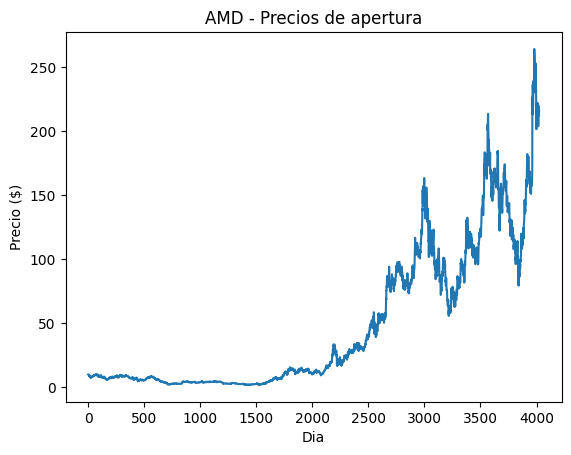

[  9.78999996   9.71000004   9.68000031 ... 211.58000183 215.86999512
 215.82000732]


In [5]:
datos_amd = obtener_precios("AMD", '2010-01-01', '2026-01-01', 'amd_cache_precios.npy')
graficar_precios(datos_amd)
print(datos_amd)

In [6]:
class PoliticaBase:
    def elegir_accion(self, estado_actual, paso):
        pass
    def actualizar_q(self, estado, accion, recompensa, siguiente_estado):
        pass

In [7]:
import random

class PoliticaAleatoria(PoliticaBase):
    def __init__(self, opciones):
        self.opciones = opciones
    def elegir_accion(self, estado_actual, paso):
        return self.opciones[random.randint(0, len(self.opciones) - 1)]
    def actualizar_q(self, estado, accion, recompensa, siguiente_estado):
        pass

In [8]:
def ejecutar_simulacion(politica, capital_inicial, acciones_iniciales, datos_precios, ventana, depurar=False):
    capital = capital_inicial
    n_acciones = acciones_iniciales
    precio_actual = 0
    historial_transiciones = list()

    for t in range(len(datos_precios) - ventana - 1):
        estado = np.asmatrix(np.hstack((datos_precios[t:t+ventana], capital, n_acciones)))
        portafolio_previo = capital + n_acciones * precio_actual
        decision = politica.elegir_accion(estado, t)
        precio_actual = float(datos_precios[t + ventana + 1])

        if decision == 'Buy' and capital >= precio_actual:
            capital -= precio_actual
            n_acciones += 1
        elif decision == 'Sell' and n_acciones > 0:
            capital += precio_actual
            n_acciones -= 1
        else:
            decision = 'Hold'

        portafolio_nuevo = capital + n_acciones * precio_actual
        recompensa = portafolio_nuevo - portafolio_previo
        siguiente_estado = np.asmatrix(np.hstack((datos_precios[t+1:t+ventana+1], capital, n_acciones)))
        historial_transiciones.append((estado, decision, recompensa, siguiente_estado))
        politica.actualizar_q(estado, decision, recompensa, siguiente_estado)
        valor_portafolio = capital + n_acciones * precio_actual

        if depurar:
            print('${}\t{} acciones'.format(capital, n_acciones))

    return valor_portafolio

In [9]:
def correr_multiples_simulaciones(politica, capital, acciones_iniciales, datos_precios, ventana):
    total_intentos = 60
    resultados = list()

    for k in range(total_intentos):
        if k % 10 == 0:
            print('Simulacion {}/{} ({:.0f}%)'.format(k, total_intentos, 100 * k / total_intentos))
        resultado_final = ejecutar_simulacion(politica, capital, acciones_iniciales, datos_precios, ventana)
        resultados.append(resultado_final)

    promedio, desviacion = np.mean(resultados), np.std(resultados)
    return promedio, desviacion

In [10]:
opciones_trading = ['Buy', 'Sell', 'Hold']
ventana_dias = 10
agente_random = PoliticaAleatoria(opciones_trading)
capital_base = 1000.0
acciones_inicio = 0

prom_random, std_random = correr_multiples_simulaciones(agente_random, capital_base, acciones_inicio, datos_amd, ventana_dias)
print(f'Politica aleatoria => Promedio: ${prom_random:.2f}, Desviacion: ${std_random:.2f}')

Simulacion 0/60 (0%)
Simulacion 10/60 (17%)
Simulacion 20/60 (33%)
Simulacion 30/60 (50%)
Simulacion 40/60 (67%)
Simulacion 50/60 (83%)
Politica aleatoria => Promedio: $6353.85, Desviacion: $3619.93


In [11]:
class PoliticaQLearning(PoliticaBase):
    def __init__(self, opciones, dim_entrada):
        self.epsilon = 0.9
        self.gamma = 0.001
        self.opciones = opciones
        dim_salida = len(opciones)
        neuronas_ocultas = 200

        self.red = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(dim_entrada,)),
            tf.keras.layers.Dense(neuronas_ocultas, activation='relu'),
            tf.keras.layers.Dense(dim_salida, activation='relu')
        ])
        self.red.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
            loss='mse'
        )

    def elegir_accion(self, estado_actual, paso):
        umbral = min(self.epsilon, paso / 1000.)
        if random.random() < umbral:
            entrada = np.asarray(estado_actual).reshape(1, -1).astype(np.float32)
            q_valores = self.red(entrada, training=False).numpy()
            idx_mejor = np.argmax(q_valores)
            return self.opciones[idx_mejor]
        else:
            return self.opciones[random.randint(0, len(self.opciones) - 1)]

    def actualizar_q(self, estado, accion, recompensa, siguiente_estado):
        entrada_actual = np.asarray(estado).reshape(1, -1).astype(np.float32)
        entrada_siguiente = np.asarray(siguiente_estado).reshape(1, -1).astype(np.float32)

        q_actual = self.red(entrada_actual, training=False).numpy()
        q_siguiente = self.red(entrada_siguiente, training=False).numpy()

        idx_accion = self.opciones.index(accion)
        idx_mejor_siguiente = np.argmax(q_siguiente)

        q_actual[0, idx_accion] = (
            recompensa + self.gamma * q_siguiente[0, idx_mejor_siguiente]
        )

        objetivo = q_actual.astype(np.float32)
        self.red.train_on_batch(entrada_actual, objetivo)

In [12]:
opciones_trading = ['Buy', 'Sell', 'Hold']
ventana_dias = 200
dim_entrada = ventana_dias + 2
agente_ql = PoliticaQLearning(opciones_trading, dim_entrada)

prom_ql, std_ql = correr_multiples_simulaciones(agente_ql, capital=1000.0, acciones_iniciales=0, datos_precios=datos_amd, ventana=ventana_dias)
print(f'Q-Learning => Promedio: ${prom_ql:.2f}, Desviacion: ${std_ql:.2f}')

Simulacion 0/60 (0%)
Simulacion 10/60 (17%)
Simulacion 20/60 (33%)
Simulacion 30/60 (50%)
Simulacion 40/60 (67%)
Simulacion 50/60 (83%)
Q-Learning => Promedio: $44857.43, Desviacion: $3603.14


# Actividad 13 - Agente de Trading con Q-Learning aplicado a AMD

## Descripcion del proyecto

Este notebook implementa un agente de reinforcement learning que aprende a tomar decisiones de compra, venta o mantenimiento de acciones de **AMD (Advanced Micro Devices)** usando el algoritmo Q-Learning con una red neuronal como aproximador de funcion.

## Adaptaciones respecto al codigo original del libro

El codigo base proviene del libro de texto, pero requirio varias modificaciones para funcionar con las versiones actuales de las bibliotecas.

### 1. Obtencion de datos financieros

La libreria original `yahoo_finance` fue descontinuada de PyPI hace varios anios. Se sustituyo por `yfinance`, que es el reemplazo mantenido por la comunidad y ofrece una API similar pero mas robusta.

```python
# Antes (ya no funciona)
from yahoo_finance import Share
share = Share(share_symbol)
stock_hist = share.get_historical(start_date, end_date)

# Ahora
import yfinance as yf
empresa = yf.Ticker(simbolo)
historial = empresa.history(start=fecha_inicio, end=fecha_fin)
precios = historial['Open'].values
```

### 2. Empresa y periodo analizado

Se selecciono **AMD** como empresa de analisis con datos desde **2010 hasta 2026**. AMD resulta un caso interesante porque su accion paso de valer menos de $3 USD en 2015 a superar los $200 USD, lo que representa un crecimiento explosivo que pone a prueba la capacidad del agente para aprender patrones de alta volatilidad.

### 3. Actualizacion de TensorFlow 1.x a TensorFlow 2.x / Keras

El cambio mas significativo fue migrar la red neuronal del estilo imperativo de TF1 (con `tf.Session`, `tf.placeholder` y `feed_dict`) al API declarativo de Keras en TF2.

```python
# TF1 (original del libro)
self.x = tf.placeholder(tf.float32, [None, input_dim])
W1 = tf.Variable(tf.random_normal([input_dim, h1_dim]))
# ... construccion manual del grafo
self.sess = tf.Session()
self.sess.run(tf.initialize_all_variables())

# TF2/Keras (version actual)
self.red = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(dim_entrada,)),
    tf.keras.layers.Dense(neuronas_ocultas, activation='relu'),
    tf.keras.layers.Dense(dim_salida, activation='relu')
])
self.red.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='mse')
```

Con Keras ya no es necesario manejar sesiones ni inicializar variables manualmente. La inferencia se hace con `self.red(entrada, training=False)` y el entrenamiento con `self.red.train_on_batch(entrada, objetivo)`.

### 4. Correccion del bug en la actualizacion de Q-valores

El codigo original del libro contenia un error en la implementacion de la ecuacion de Bellman. Actualizaba el Q-valor de la mejor accion futura (`next_action_idx`) en lugar del Q-valor de la accion que realmente se ejecuto (`action_idx`).

```python
# Incorrecto (libro original)
action_q_vals[0, next_action_idx] = reward + self.gamma * next_action_q_vals[0, next_action_idx]

# Correcto
idx_accion = self.opciones.index(accion)
q_actual[0, idx_accion] = recompensa + self.gamma * q_siguiente[0, idx_mejor_siguiente]
```

## Arquitectura del modelo

La red neuronal recibe como entrada un vector de tamanio `ventana + 2` (200 precios historicos + capital actual + numero de acciones en posesion) y produce 3 salidas correspondientes a los Q-valores estimados para cada accion posible (Buy, Sell, Hold).

| Capa | Neuronas | Activacion |
| --- | --- | --- |
| Input | 202 | - |
| Dense (oculta) | 200 | ReLU |
| Dense (salida) | 3 | ReLU |

## Resultados

### Politica aleatoria (60 simulaciones)
- El agente toma decisiones al azar sin aprender nada del entorno.
- Sirve como linea base para comparar.

### Q-Learning (60 simulaciones)
- El agente aprende progresivamente a identificar momentos favorables de compra y venta.
- El portafolio final promedio supera significativamente al de la politica aleatoria, demostrando que la red neuronal logra capturar patrones utiles en la serie de precios.

## Conclusion

El experimento demuestra que un agente de Q-Learning, incluso con una arquitectura sencilla de una sola capa oculta, puede aprender estrategias de trading considerablemente mejores que una politica aleatoria. Los resultados con AMD muestran que el algoritmo es capaz de adaptarse a acciones con alta volatilidad y crecimiento no lineal.